In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from google.colab import drive
drive.mount('/content/drive')

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Battery_RUL.csv')
df.head()

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


In [ ]:
print("DATA SHAPE")
df.shape


DATA SHAPE


(15064, 9)

In [ ]:
print("DATA TYPES")
print(df.dtypes)

DATA TYPES
Cycle_Index                  float64
Discharge Time (s)           float64
Decrement 3.6-3.4V (s)       float64
Max. Voltage Dischar. (V)    float64
Min. Voltage Charg. (V)      float64
Time at 4.15V (s)            float64
Time constant current (s)    float64
Charging time (s)            float64
RUL                            int64
dtype: object


In [ ]:
df.describe()

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
count,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000
mean,556.155005,4581.273960,1239.784672,3.908176,3.577904,3768.336171,5461.266970,10066.496204,554.194172
std,322.378480,33144.012077,15039.589269,0.091003,0.123695,9129.552477,25155.845202,26415.354121,322.434514
min,1.000000,8.690000,-397645.908000,3.043000,3.022000,-113.584000,5.980000,5.980000,0.000000
25%,271.000000,1169.310000,319.600000,3.846000,3.488000,1828.884179,2564.310000,7841.922500,277.000000
50%,560.000000,1557.250000,439.239471,3.906000,3.574000,2930.203500,3824.260000,8320.415000,551.000000
75%,833.000000,1908.000000,600.000000,3.972000,3.663000,4088.326500,5012.350000,8763.282500,839.000000
max,1134.000000,958320.370000,406703.768000,4.363000,4.379000,245101.117000,880728.100000,880728.100000,1133.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15064 entries, 0 to 15063
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Cycle_Index                15064 non-null  float64
 1   Discharge Time (s)         15064 non-null  float64
 2   Decrement 3.6-3.4V (s)     15064 non-null  float64
 3   Max. Voltage Dischar. (V)  15064 non-null  float64
 4   Min. Voltage Charg. (V)    15064 non-null  float64
 5   Time at 4.15V (s)          15064 non-null  float64
 6   Time constant current (s)  15064 non-null  float64
 7   Charging time (s)          15064 non-null  float64
 8   RUL                        15064 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.0 MB


In [ ]:
print("MISSING VALUES")
print(df.isnull().sum())

MISSING VALUES
Cycle_Index                  0
Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
dtype: int64


In [ ]:
print("DUPLICATE ROWS")
duplicates = df.duplicated().sum()
print(duplicates)

DUPLICATE ROWS
0


# Visualization

## Box Plot

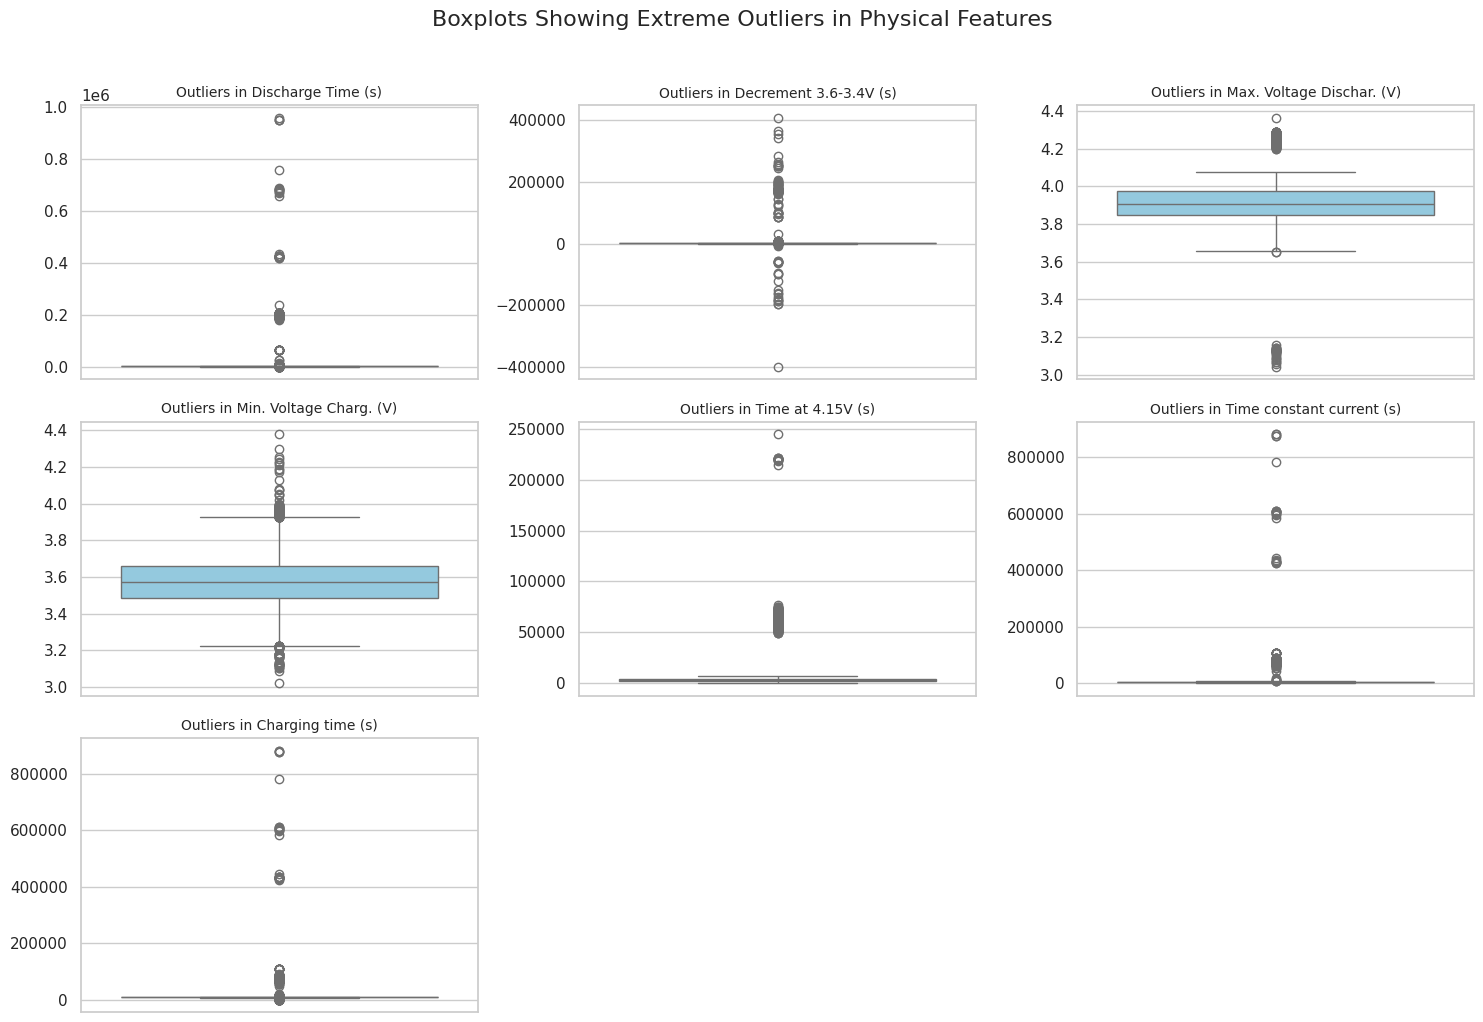

In [ ]:
plt.figure(figsize=(15, 10))
features_to_plot = [c for c in df.columns if c not in ['RUL', 'Cycle_Index']]

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers in {col}', fontsize=10)
    plt.ylabel('')

plt.suptitle("Boxplots Showing Extreme Outliers in Physical Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Correlation Heatmap

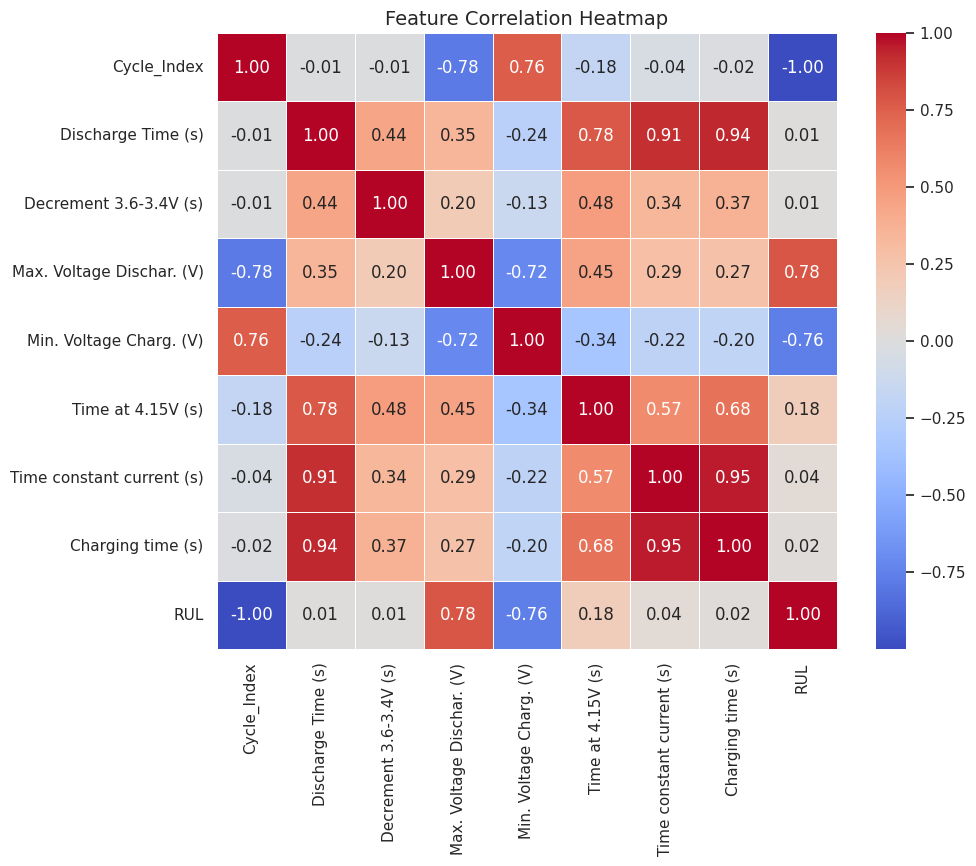

In [ ]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()

## Feature Selection & Train-Test Split

In [ ]:
X = df.drop(columns=['RUL', 'Cycle_Index'])
y = df['RUL']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features (X) used for training: {list(X.columns)}")
print(f"\nTraining Data Shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing Data Shape: X={X_test.shape}, y={y_test.shape}")

Features (X) used for training: ['Discharge Time (s)', 'Decrement 3.6-3.4V (s)', 'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)', 'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)']

Training Data Shape: X=(12051, 7), y=(12051,)
Testing Data Shape: X=(3013, 7), y=(3013,)


## Outlier Handling & Feature Scaling

In [ ]:
pt = PowerTransformer(method='yeo-johnson')

X_train_scaled = pt.fit_transform(X_train)
X_test_scaled = pt.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

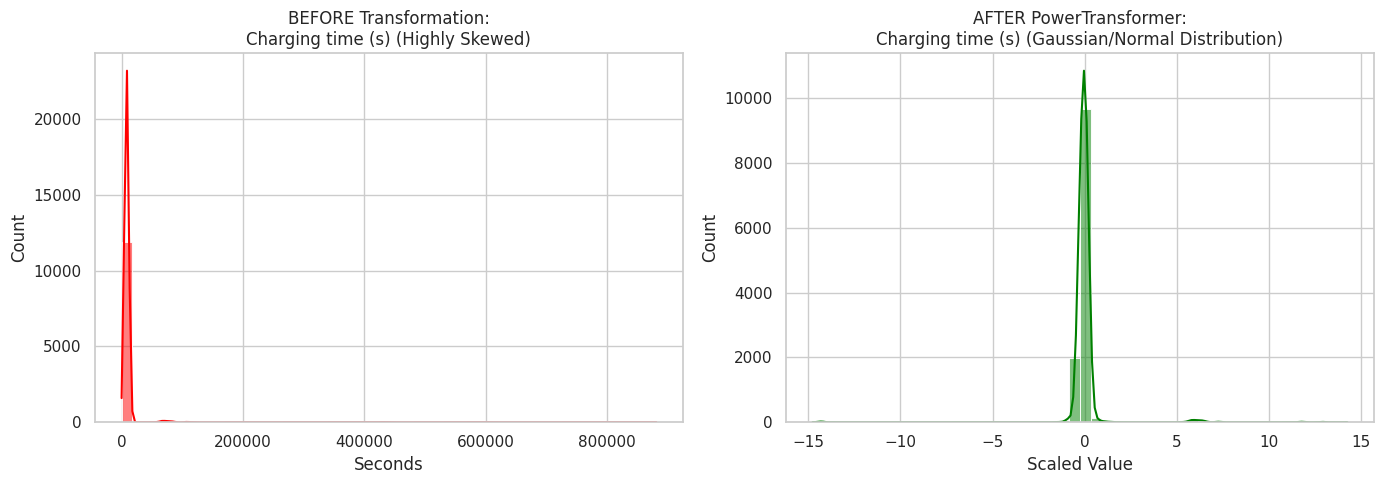

In [ ]:
feature_to_compare = 'Charging time (s)'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(X_train[feature_to_compare], bins=50, kde=True, ax=axes[0], color='red')
axes[0].set_title(f'BEFORE Transformation:\n{feature_to_compare} (Highly Skewed)')
axes[0].set_xlabel("Seconds")

sns.histplot(X_train_scaled[feature_to_compare], bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title(f'AFTER PowerTransformer:\n{feature_to_compare} (Gaussian/Normal Distribution)')
axes[1].set_xlabel("Scaled Value")

plt.tight_layout()
plt.show()

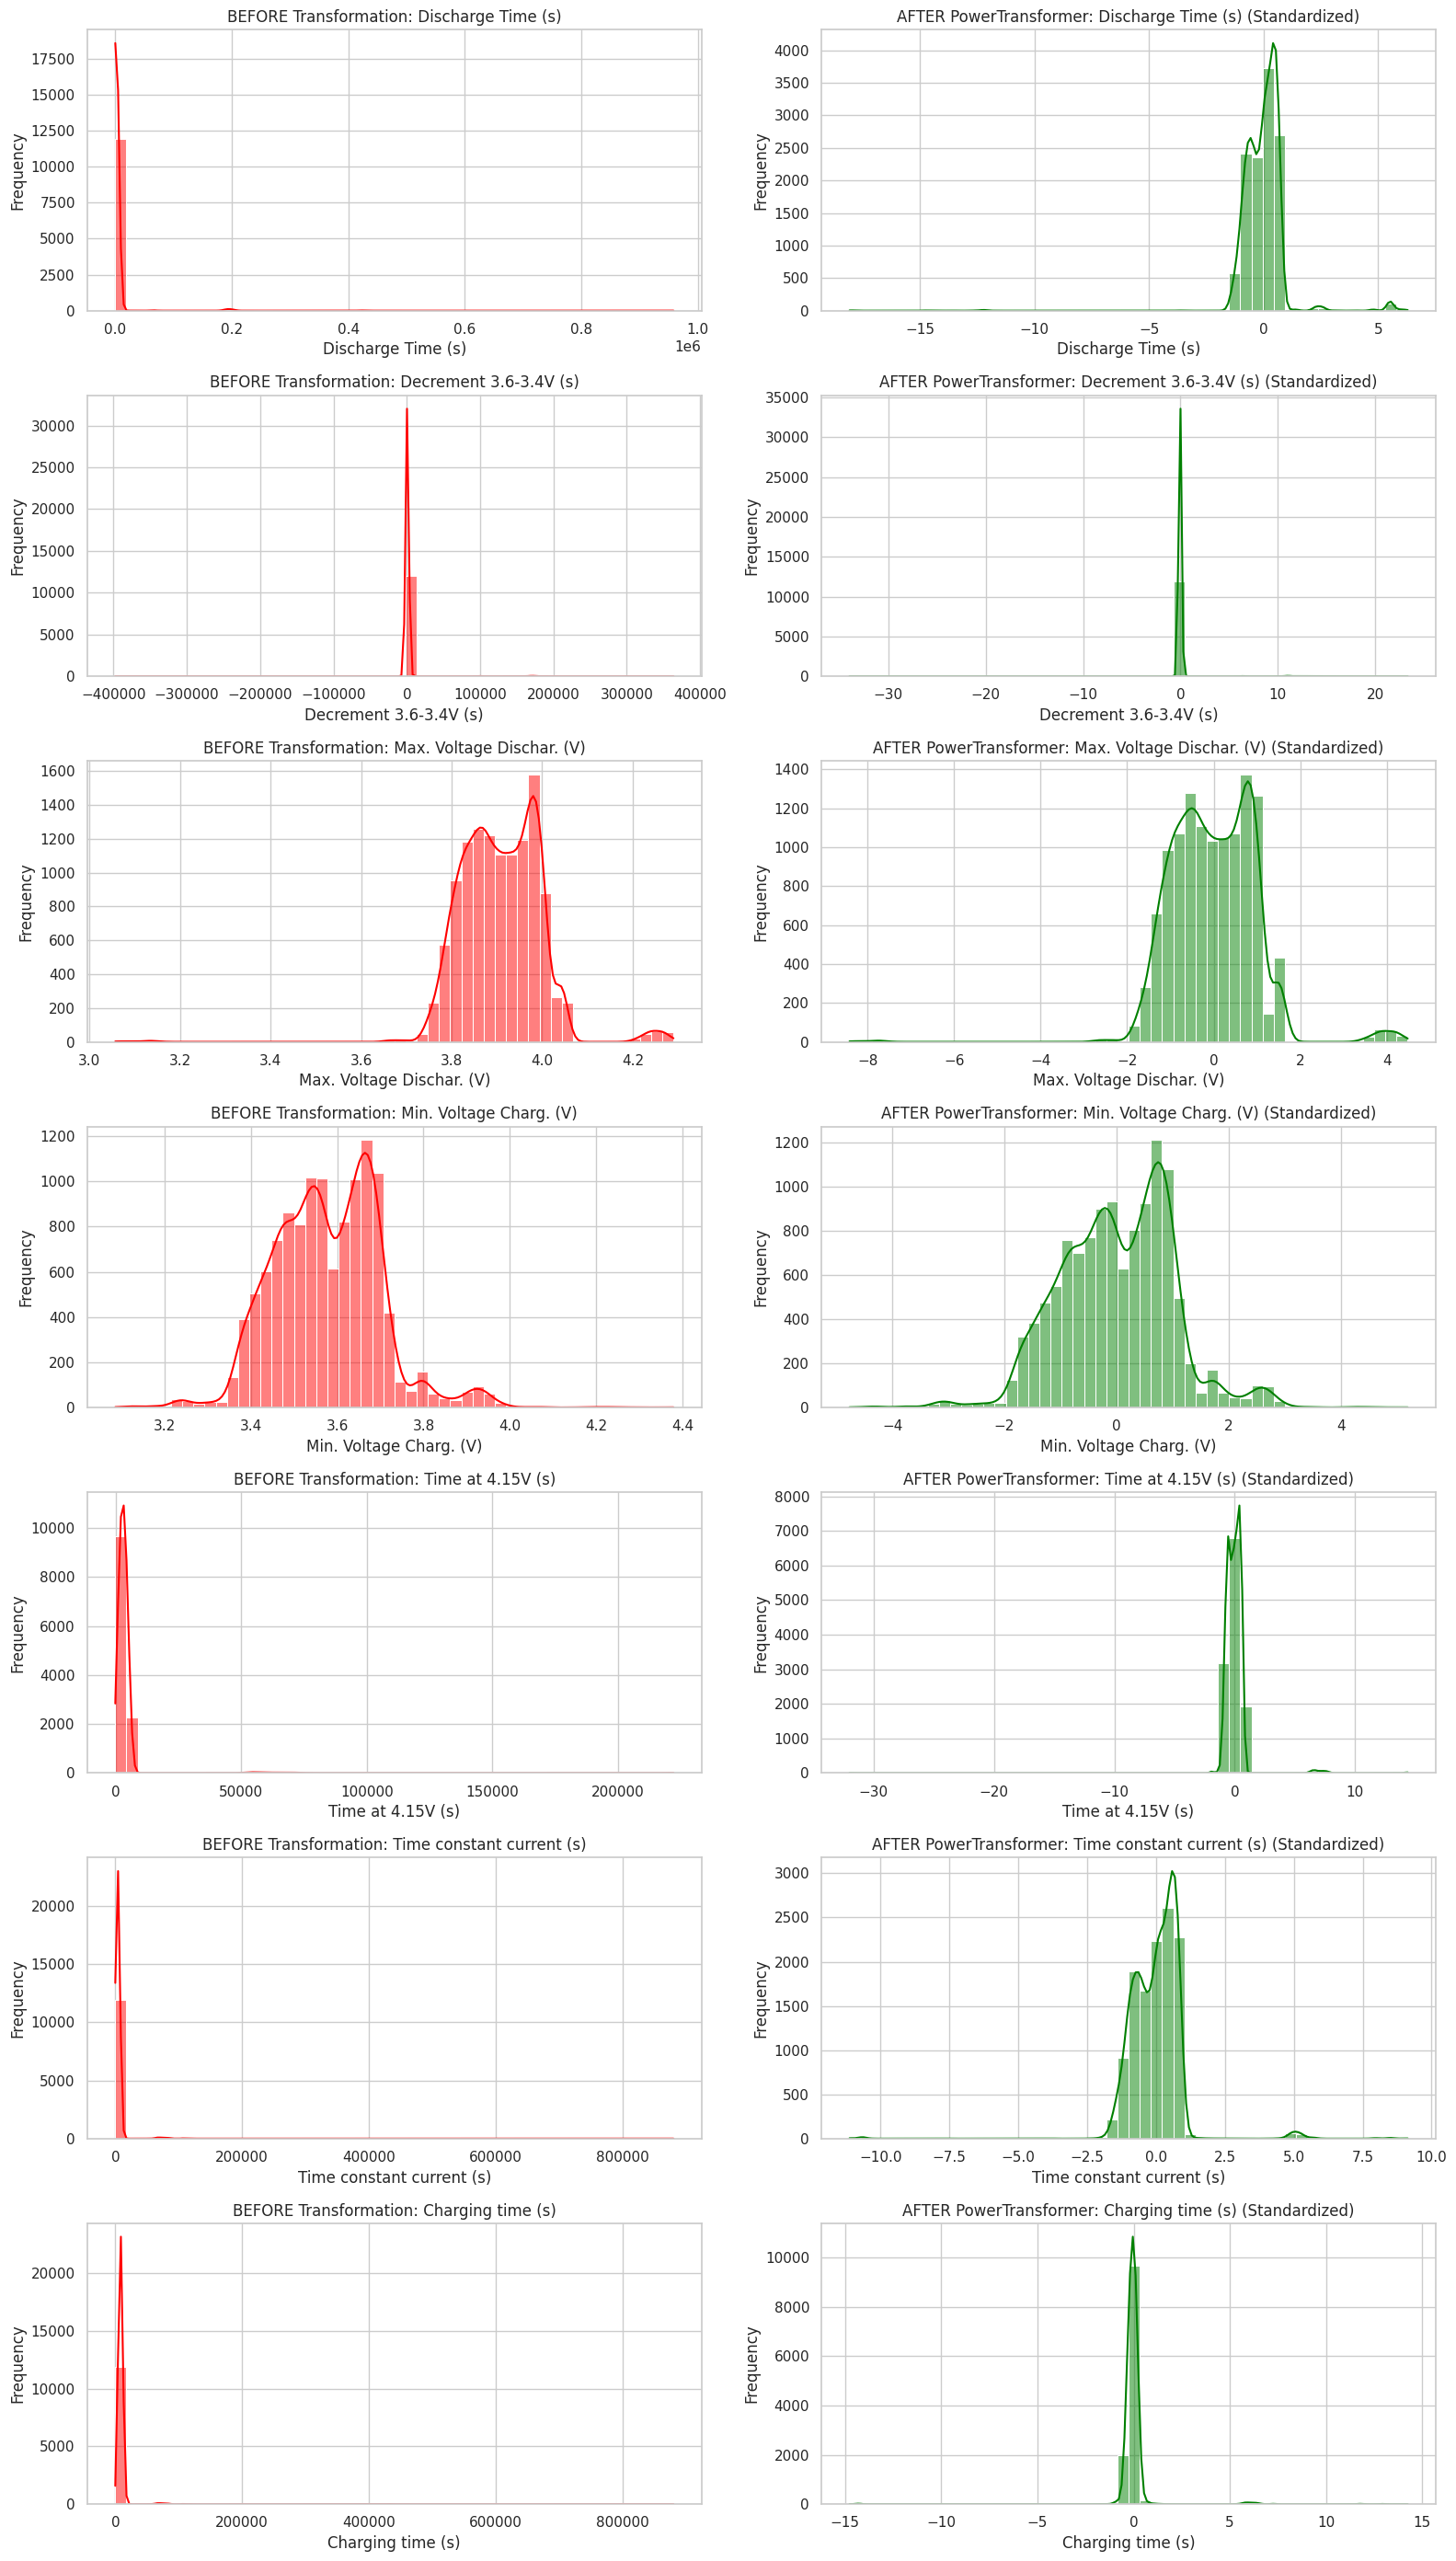

In [ ]:
# Get feature names
features = X_train.columns

# Count total features
num_features = len(features)

# Create subplot layout
fig, axes = plt.subplots(
    num_features,
    2,
    figsize=(16, 4 * num_features)
)

# Loop through each feature
for i, col in enumerate(features):

    # BEFORE transformation
    sns.histplot(
        X_train[col],
        bins=50,
        kde=True,
        ax=axes[i, 0],
        color='red'
    )

    axes[i, 0].set_title(
        f'BEFORE Transformation: {col}',
        fontsize=12
    )

    axes[i, 0].set_ylabel('Frequency')

    # AFTER transformation
    sns.histplot(
        X_train_scaled[col],
        bins=50,
        kde=True,
        ax=axes[i, 1],
        color='green'
    )

    axes[i, 1].set_title(
        f'AFTER PowerTransformer: {col} (Standardized)',
        fontsize=12
    )

    axes[i, 1].set_ylabel('Frequency')

# Adjust spacing
plt.tight_layout()

# Show plots
plt.show()

# Model Training

In [ ]:
# ==========================================
# INITIALIZE ALL MODELS
# ==========================================

# Basic Models
lr_model = LinearRegression()

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Additional Models
ridge_model = Ridge(alpha=1.0)

lasso_model = Lasso(alpha=0.01)

elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5
)

dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

et_model = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

ada_model = AdaBoostRegressor(
    n_estimators=100,
    random_state=42
)

svr_model = SVR(
    kernel='rbf'
)

knn_model = KNeighborsRegressor(
    n_neighbors=5
)

# ==========================================
# STORE ALL MODELS IN DICTIONARY
# ==========================================

models = {

    "Linear Regression": lr_model,

    "Random Forest": rf_model,

    "XGBoost": xgb_model,

    "Ridge Regression": ridge_model,

    "Lasso Regression": lasso_model,

    "Elastic Net": elastic_model,

    "Decision Tree": dt_model,

    "Gradient Boosting": gb_model,

    "Extra Trees": et_model,

    "AdaBoost": ada_model,

    "SVR": svr_model,

    "KNN": knn_model
}

# ==========================================
# TRAIN ALL MODELS
# ==========================================

print("Training models... please wait.")

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train)

print("\nAll models trained successfully!")


Training models... please wait.
Training Linear Regression...
Training Random Forest...
Training XGBoost...
Training Ridge Regression...
Training Lasso Regression...
Training Elastic Net...
Training Decision Tree...
Training Gradient Boosting...
Training Extra Trees...
Training AdaBoost...
Training SVR...
Training KNN...

All models trained successfully!



--- Model Performance Comparison ---
                Model        MAE        RMSE  R2 Score
8         Extra Trees   8.730680   20.431472  0.995970
1       Random Forest  11.084913   27.531636  0.992682
11                KNN  10.314570   33.408844  0.989225
2             XGBoost  19.359943   33.669417  0.989056
6       Decision Tree  20.623456   41.484851  0.983386
7   Gradient Boosting  31.927726   45.001736  0.980449
9            AdaBoost  57.091395   68.602184  0.954566
10                SVR  52.019149   83.408888  0.932838
5         Elastic Net  82.048752  126.924143  0.844479
3    Ridge Regression  81.112157  127.912989  0.842046
4    Lasso Regression  81.103761  127.926591  0.842013
0   Linear Regression  81.095875  127.934970  0.841992

Best Model: Extra Trees


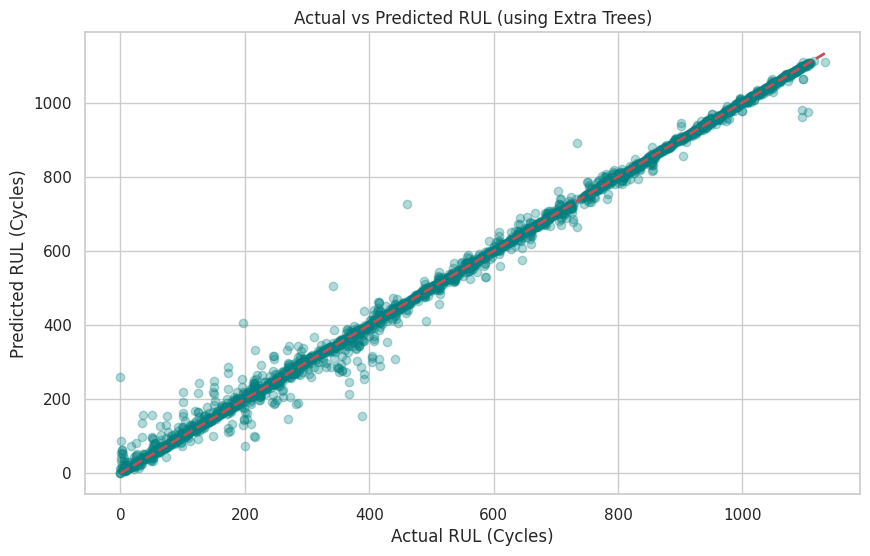

In [ ]:
def get_metrics(model, X, y_true, name):

    # Predict values
    y_pred = model.predict(X)

    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    # Return metrics
    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    }

# ==========================================
# EVALUATE ALL MODELS
# ==========================================

results = []

for name, model in models.items():

    metrics = get_metrics(
        model,
        X_test_scaled,
        y_test,
        name
    )

    results.append(metrics)

# ==========================================
# CREATE RESULTS DATAFRAME
# ==========================================

results_df = pd.DataFrame(results)

# Sort by highest R2 Score
results_df = results_df.sort_values(
    by='R2 Score',
    ascending=False
)

# ==========================================
# DISPLAY RESULTS
# ==========================================

print("\n--- Model Performance Comparison ---")

print(results_df)

# ==========================================
# SELECT BEST MODEL
# ==========================================

best_model_name = results_df.iloc[0]['Model']

best_model = models[best_model_name]

print(f"\nBest Model: {best_model_name}")

# ==========================================
# PREDICT USING BEST MODEL
# ==========================================

y_pred_best = best_model.predict(X_test_scaled)

# ==========================================
# VISUALIZE RESULTS
# ==========================================

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.3,
    color='teal'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    '--r',
    linewidth=2
)

plt.title(
    f'Actual vs Predicted RUL (using {best_model_name})'
)

plt.xlabel('Actual RUL (Cycles)')

plt.ylabel('Predicted RUL (Cycles)')

plt.grid(True)

plt.show()

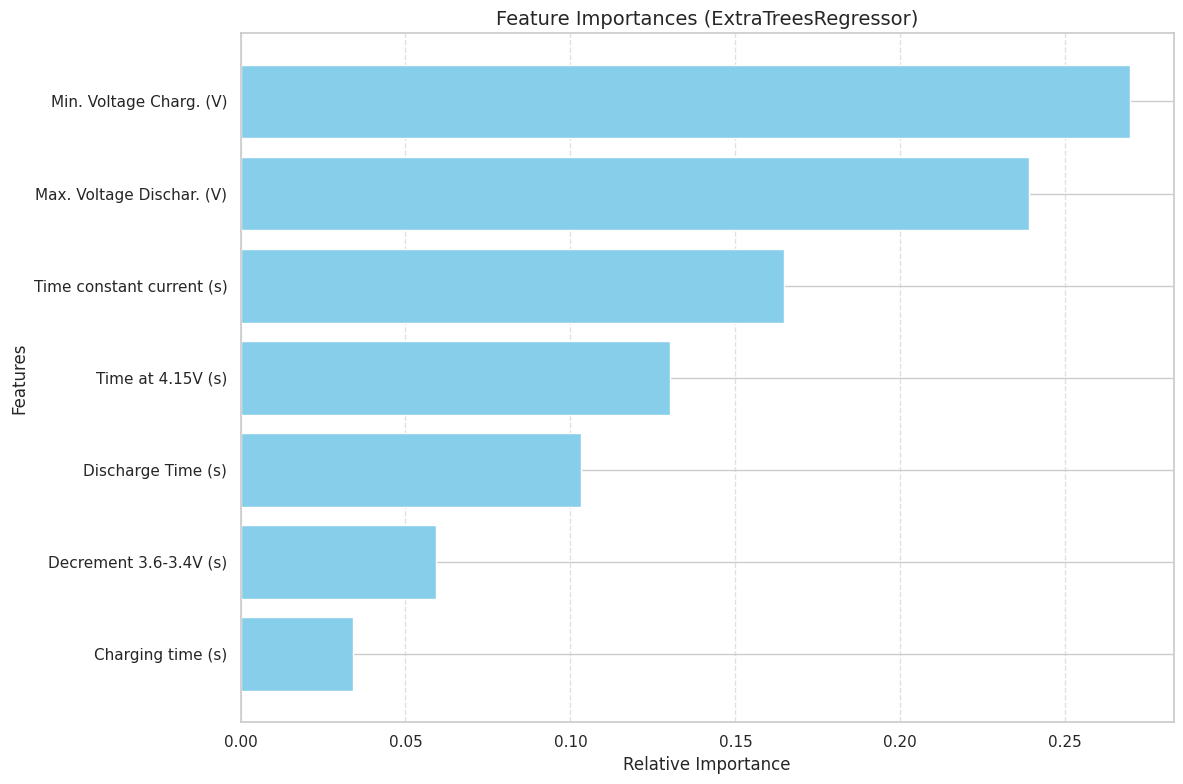


--- Feature Importance Table ---
                     Feature  Importance
3    Min. Voltage Charg. (V)    0.269474
2  Max. Voltage Dischar. (V)    0.239077
5  Time constant current (s)    0.164826
4          Time at 4.15V (s)    0.130072
0         Discharge Time (s)    0.103229
1     Decrement 3.6-3.4V (s)    0.059113
6          Charging time (s)    0.034209


In [ ]:
# ==========================================
# FEATURE IMPORTANCE VISUALIZATION
# ==========================================

# Select model for feature importance
# Tree-based models support feature_importances_

importance_model = et_model

# You can also use:
# importance_model = xgb_model
# importance_model = et_model

# Get feature importance values
importances = importance_model.feature_importances_

# Get feature names
feature_names = X_train.columns

# Sort features by importance
indices = np.argsort(importances)

# ==========================================
# CREATE PLOT
# ==========================================

plt.figure(figsize=(12, 8))

# Horizontal bar chart
plt.barh(
    range(len(indices)),
    importances[indices],
    color='skyblue',
    align='center'
)

# Add feature names
plt.yticks(
    range(len(indices)),
    [feature_names[i] for i in indices]
)

# Labels and title
plt.xlabel('Relative Importance', fontsize=12)

plt.ylabel('Features', fontsize=12)

plt.title(
    f'Feature Importances ({type(importance_model).__name__})',
    fontsize=14
)

# Add grid
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Tight layout
plt.tight_layout()

# Show plot
plt.show()

# ==========================================
# OPTIONAL: DISPLAY IMPORTANCE VALUES
# ==========================================

importance_df = pd.DataFrame({

    'Feature': feature_names,

    'Importance': importances
})

# Sort descending
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n--- Feature Importance Table ---")

print(importance_df)

In [ ]:
joblib.dump(et_model, 'battery_rul_et_model.pkl')

['battery_rul_et_model.pkl']

In [ ]:
joblib.dump(pt, 'power_transformer.pkl')

['power_transformer.pkl']

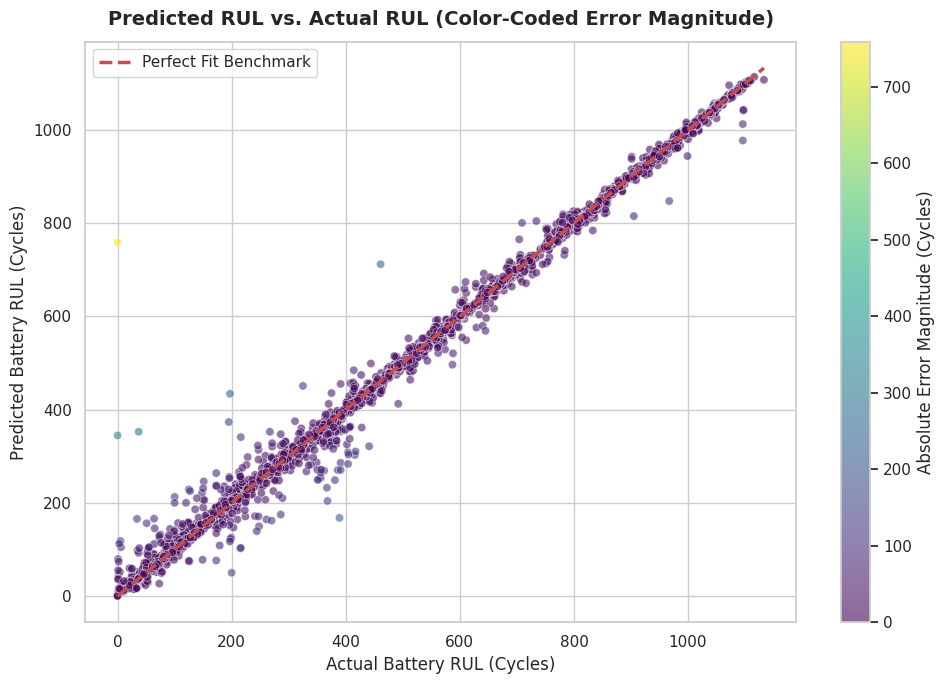

In [ ]:
y_pred = rf_model.predict(X_test_scaled)

# 2. Calculate absolute error for each prediction point
errors = np.abs(y_test - y_pred)

# 3. Set up the plotting canvas with standard clean academic formatting
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid") # Ensures crisp background grids for paper clarity

# 4. Draw the scatter plot where dot colors reflect error magnitude
scatter = plt.scatter(y_test, y_pred, c=errors, cmap='viridis', alpha=0.6, edgecolors='w', linewidths=0.5)

# Add colorbar mapping indicator
colorbar = plt.colorbar(scatter)
colorbar.set_label('Absolute Error Magnitude (Cycles)', fontsize=12)

# 5. Draw the diagonal "Perfect Fit" benchmark line
line_range = [y_test.min(), y_test.max()]
plt.plot(line_range, line_range, 'r--', lw=2.5, label='Perfect Fit Benchmark')

# 6. Final labels, sizing, and clean layout optimization
plt.title('Predicted RUL vs. Actual RUL (Color-Coded Error Magnitude)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Actual Battery RUL (Cycles)', fontsize=12)
plt.ylabel('Predicted Battery RUL (Cycles)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)

plt.tight_layout()

# Save a copy directly into your workspace at high resolution for paper integration
plt.savefig('scatter_error_magnitude.png', dpi=300)
plt.show()

In [ ]:
sample_input = X_test_scaled.iloc[220:221]
actual_rul = y_test.iloc[220]

predicted_rul = rf_model.predict(sample_input)

print(f"Actual RUL: {actual_rul} cycles")
print(f"Model Prediction: {predicted_rul[0]:.2f} cycles")
print(f"Difference: {abs(actual_rul - predicted_rul[0]):.2f} cycles")

Actual RUL: 769 cycles
Model Prediction: 766.71 cycles
Difference: 2.29 cycles


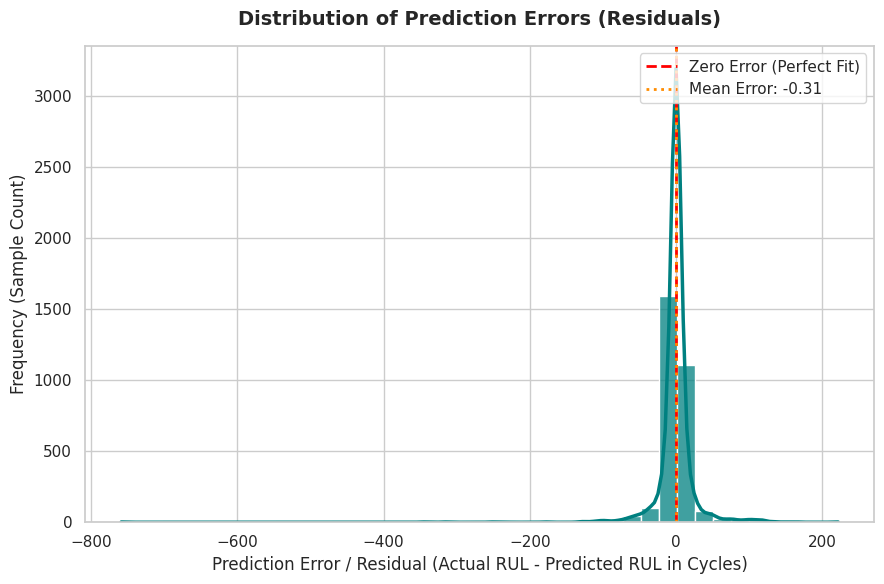

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate the residuals (errors)
# Ensure y_pred contains your Random Forest predictions: y_pred = rf_model.predict(X_test_scaled)
residuals = y_test - y_pred

# 2. Configure academic styling parameters
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")  # Clean white grid layout matching MDPI standard

# 3. Create the teal histogram with Kernel Density Estimate (KDE)
sns.histplot(
    residuals,
    kde=True,
    color='teal',
    bins=40,
    edgecolor='white',
    alpha=0.75,
    line_kws={'linewidth': 2.5}
)

# 4. Add structural lines for interpretation
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error (Perfect Fit)')
plt.axvline(x=np.mean(residuals), color='darkorange', linestyle=':', linewidth=2, label=f'Mean Error: {np.mean(residuals):.2f}')

# 5. Format labels and titles with clear font scales
plt.title('Distribution of Prediction Errors (Residuals)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Prediction Error / Residual (Actual RUL - Predicted RUL in Cycles)', fontsize=12)
plt.ylabel('Frequency (Sample Count)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)

# Adjust boundaries tightly for crisp screenshot export
plt.tight_layout()

# Save image directly for your paper document
plt.savefig('error_distribution_histogram.png', dpi=300)
plt.show()